[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatheusSilveiraVicente/case-especialista-dados/blob/main/notebooks/01_eda.ipynb)

# 01 — Análise exploratória: vendas do e-commerce (nov/2025 a jun/2026)

**Perguntas do case:** preço médio de venda, potencial por dia da semana e flutuação ao longo do dia.
**Como ler:** cada seção traz a pergunta, o gráfico e a leitura de negócio. A lógica fica em `src/eda.py` e `src/data_loader.py`; o notebook só orquestra.

In [1]:
# Setup: roda localmente ou no Google Colab
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "MatheusSilveiraVicente/case-especialista-dados"

if IN_COLAB:
    pasta = Path("/content/case-especialista-dados")
    if not pasta.exists():
        url = f"https://github.com/{REPO}.git"
        subprocess.run(["git", "clone", "-q", url, str(pasta)], check=True, capture_output=True)
    os.chdir(pasta)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna", "holidays", "shap", "lightgbm", "xgboost", "statsmodels", "pyarrow"], check=True)
    if not Path("data/raw/vendas.csv").exists():
        from google.colab import files
        print("Envie o CSV do case (Dados - Case Técnico Espec I.csv):")
        enviado = files.upload()
        Path("data/raw").mkdir(parents=True, exist_ok=True)
        Path(next(iter(enviado))).rename("data/raw/vendas.csv")
elif Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Ambiente:", "Colab" if IN_COLAB else "local")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, display
from src import eda
from src.data_loader import load_raw, quality_report, to_daily
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

Ambiente: local


## 1. Qualidade do dado

Antes de qualquer insight: o que a base tem de problema e como foi tratado (detalhes em `docs/decisoes_tecnicas.md`, D03-D05).

In [2]:
bruto = load_raw()
pd.Series(quality_report(bruto))

n_linhas                                        89566
n_duplicatas_chave                                  0
n_nulos                                             0
n_categoria_invalida                             5341
pct_receita_categoria_invalida                   5.97
n_receita_negativa                               3513
soma_receita_negativa                  -21,051,829.53
n_receita_zero                                    898
dt_min                            2025-11-01 00:00:00
dt_max                            2026-06-30 23:00:00
n_horas_faltantes                                   0
pct_grade_preenchida                            90.63
dtype: object

**Leitura**
- **6% da receita com categoria corrompida** (um número aleatório no lugar do nome). Irrecuperável: agrupado como "Nao mapeada", entra no total e sai das análises por categoria.
- **3.513 linhas com receita negativa (−R$ 21 mi, 4,3% da receita)**: tratadas como estornos. Ficam no líquido e são reportadas à parte.
- **Nenhuma hora faltando; 9,4% da grade de 8 categorias legíveis não tem venda**. Ao incluir "Nao mapeada" como nona categoria, a grade completada tem 15,2% de zeros.

In [3]:
g = eda.carregar_grade()
eda.kpis_gerais(g).to_frame("valor")

,valor
receita_mi,490.31
pedidos_mi,6.52
ticket_medio,75.19
preco_medio,49.55
itens_por_pedido,1.52
taxa_desconto,0.44
estorno_pct_receita,0.04


## 2. A série diária: dois regimes

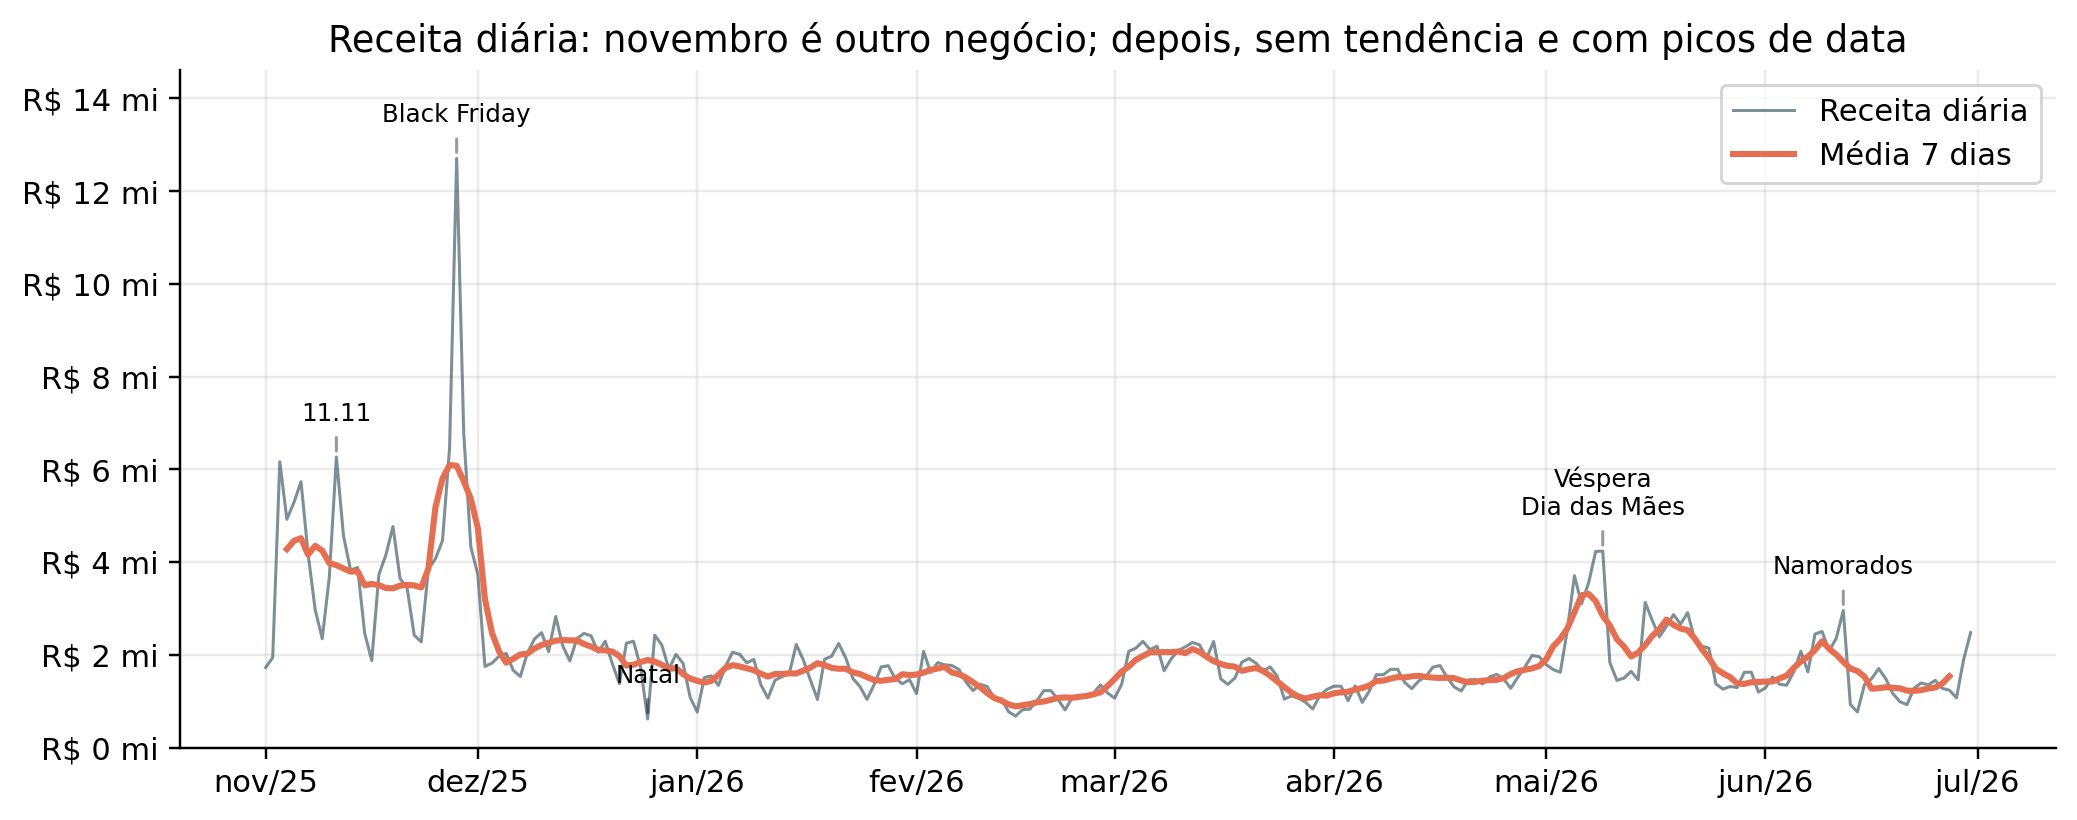

,evento,data,receita_mi,x_mediana_geral,x_media_mes
0,11.11,2025-11-11,6.27,3.70,1.46
1,Black Friday,2025-11-28,12.71,7.51,2.96
2,Natal,2025-12-25,0.62,0.37,0.30
3,Véspera Dia das Mães,2026-05-09,4.24,2.50,1.87
4,Namorados,2026-06-12,2.96,1.75,1.87
5,Dia das Mães,2026-05-10,1.84,1.09,0.81


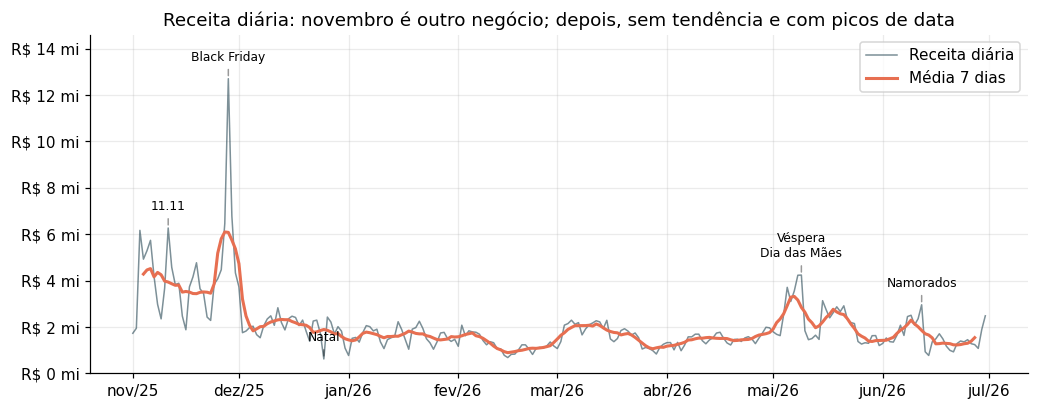

In [4]:
eda.fig_serie_diaria(g); display(Image("reports/figures/eda_01_serie_diaria.png"))
eda.eventos(g)

**Leitura**
- **Novembro é outro negócio**: 26% da receita e 34% dos pedidos dos 8 meses. Não é só a Black Friday (7,5× a mediana diária): 11.11 e vários dias de campanha passam de 3×.
- **O Natal vende o mês, não o dia:** as semanas de dezembro faturam R$ 13–16 mi, contra R$ 7–12 mi no início do ano, mas o dia 25 é o pior da base. A compra de presente acontece antes da data.
- **Dia das Mães tem pico na véspera** (sábado 09/05), não no domingo. Dia dos Namorados: 1,9× a média de junho.
- Fora dos eventos **não há tendência de longo prazo** para extrapolar; as variações de nível vêm das datas comerciais e do início do ano.

## 3. Potencial por dia da semana

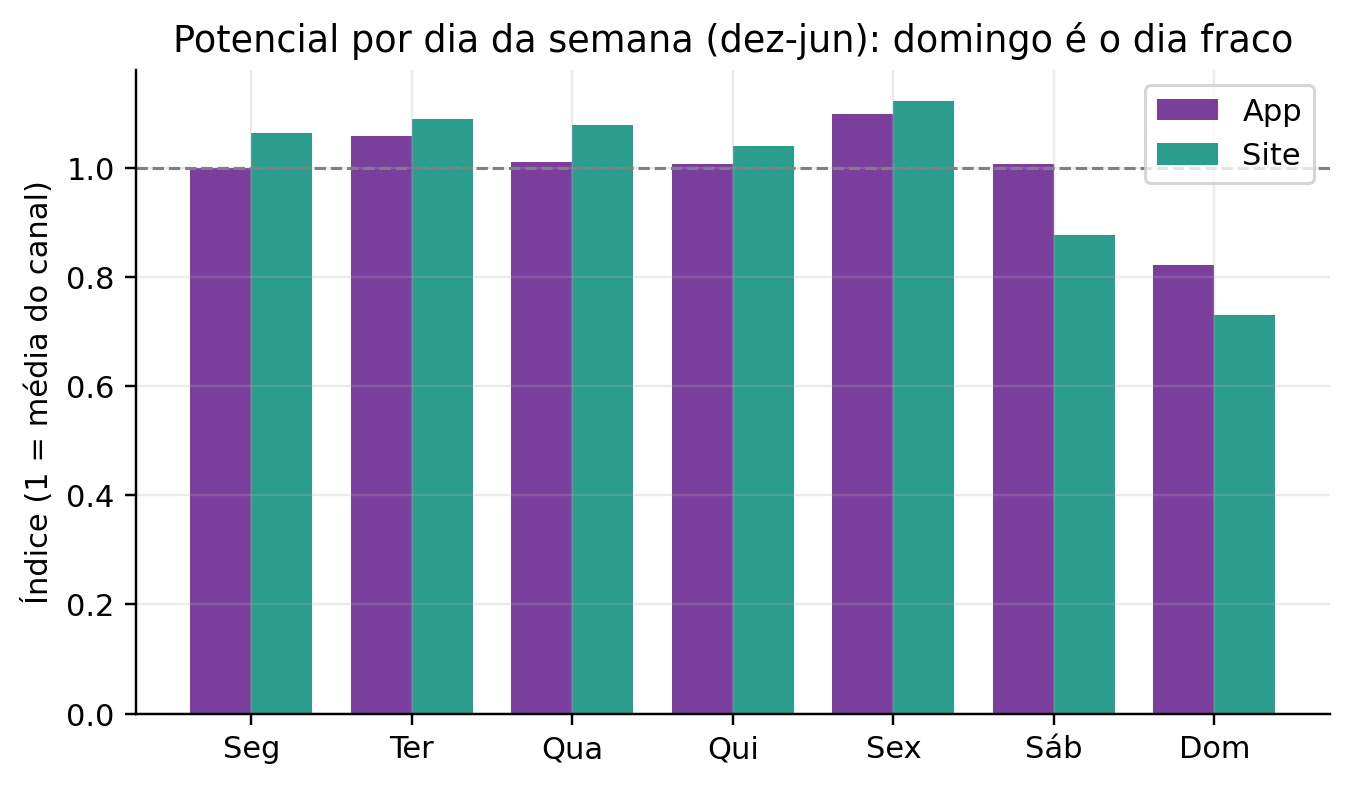

canal,App,Site,Total
dia_semana,,,
0,1.00,1.06,1.01
1,1.06,1.09,1.07
2,1.01,1.08,1.03
3,1.01,1.04,1.01
4,1.10,1.12,1.10
5,1.01,0.88,0.98
6,0.82,0.73,0.80


Índice de domingo no total: -20.0%


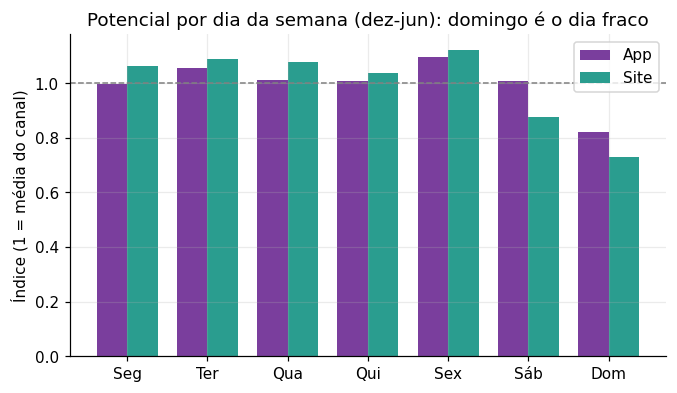

In [5]:
eda.fig_dia_semana(g); display(Image("reports/figures/eda_02_dia_semana.png"))
indices_semana = eda.indice_dia_semana(g)
display(indices_semana)
print(f"Índice de domingo no total: {indices_semana.loc[6, 'Total'] - 1:+.1%}")

**Leitura** (dez-jun, sem a distorção de novembro)
- **Pela média, sexta é o melhor dia** nos dois canais; **domingo, o pior**: total −20%, App −18% e Site −27%.
- **O App segura o fim de semana**: sábado do App está na média; o do Site cai 12%. Comunicação de fim de semana rende mais no App.
- O vale de domingo é uma oportunidade, não receita garantida: o teto contra o dia médio é cerca de R$ 1,5 mi/mês.

## 4. Flutuação ao longo do dia

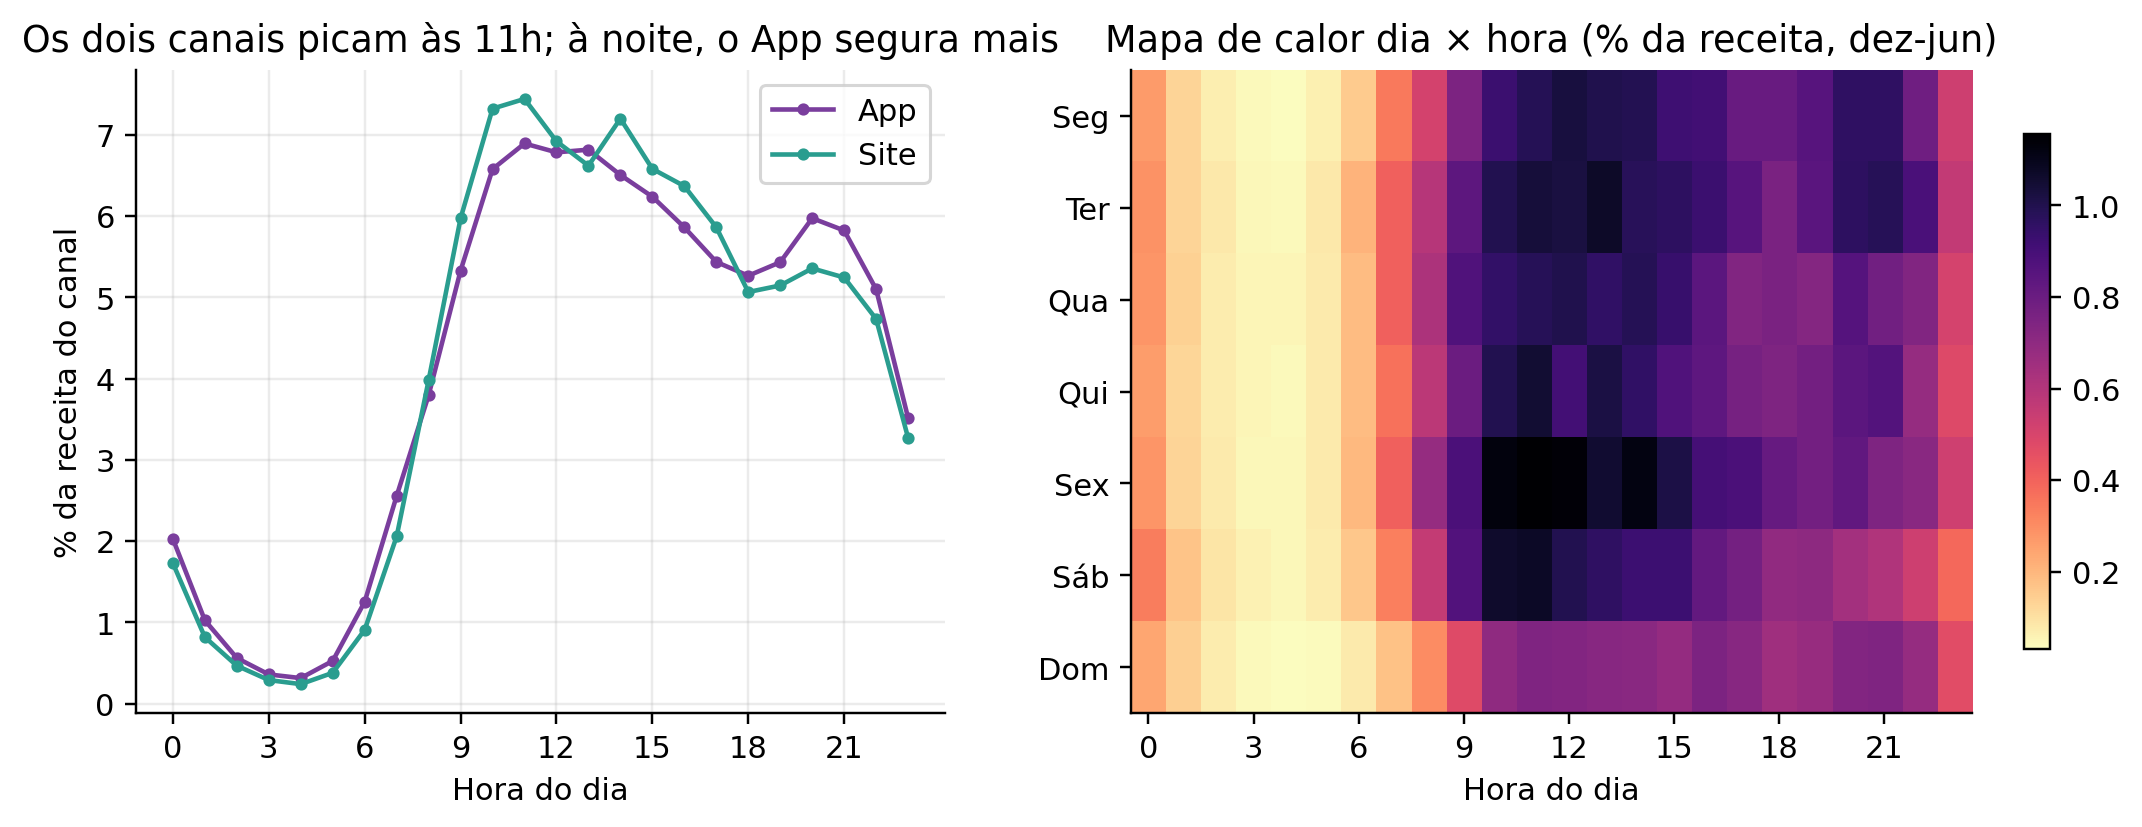

canal,App,Site
faixa_horaria,,
Madrugada,75.05,81.44
Manhã,83.46,91.43
Tarde,82.76,90.13
Noite,80.74,88.88


categoria            CABELOS  CORPO E BANHO  FACIAL  GIFTS  MAQUIAGEM  \
canal faixa_horaria                                                     
App   Madrugada         3.50          17.40    1.90  10.70       3.80   
      Manhã             2.80          17.00    1.50  12.20       3.00   
      Tarde             2.90          16.60    1.30  11.60       3.00   
      Noite             3.30          16.90    1.60  10.80       3.50   
Site  Madrugada         3.10          14.80    1.80  11.80       4.50   
      Manhã             3.10          15.90    1.80  13.10       4.40   
      Tarde             2.90          15.90    1.70  12.90       4.40   
      Noite             3.40          15.40    1.80  11.90       4.60   

categoria            PERF. DE ENTRADA E DEOS  PERFUMARIA FEMININA  \
canal faixa_horaria                                                 
App   Madrugada                        12.20                23.60   
      Manhã                            12.70                23.60   
      Tarde                            12.20                24.30   
      Noite                            12.00                24.70   
Site  Madrugada                        11.60                21.80   
      Manhã                            12.00                22.00   
      Tarde                            11.80                22.40   
      Noite                            11.50                22.30   

categoria            PERFUMARIA MASCULINA  
canal faixa_horaria                        
App   Madrugada                     26.90  
      Manhã                         27.20  
      Tarde                         28.10  
      Noite                         27.10  
Site  Madrugada                     30.40  
      Manhã                         27.70  
      Tarde                         28.00  
      Noite                         29.10

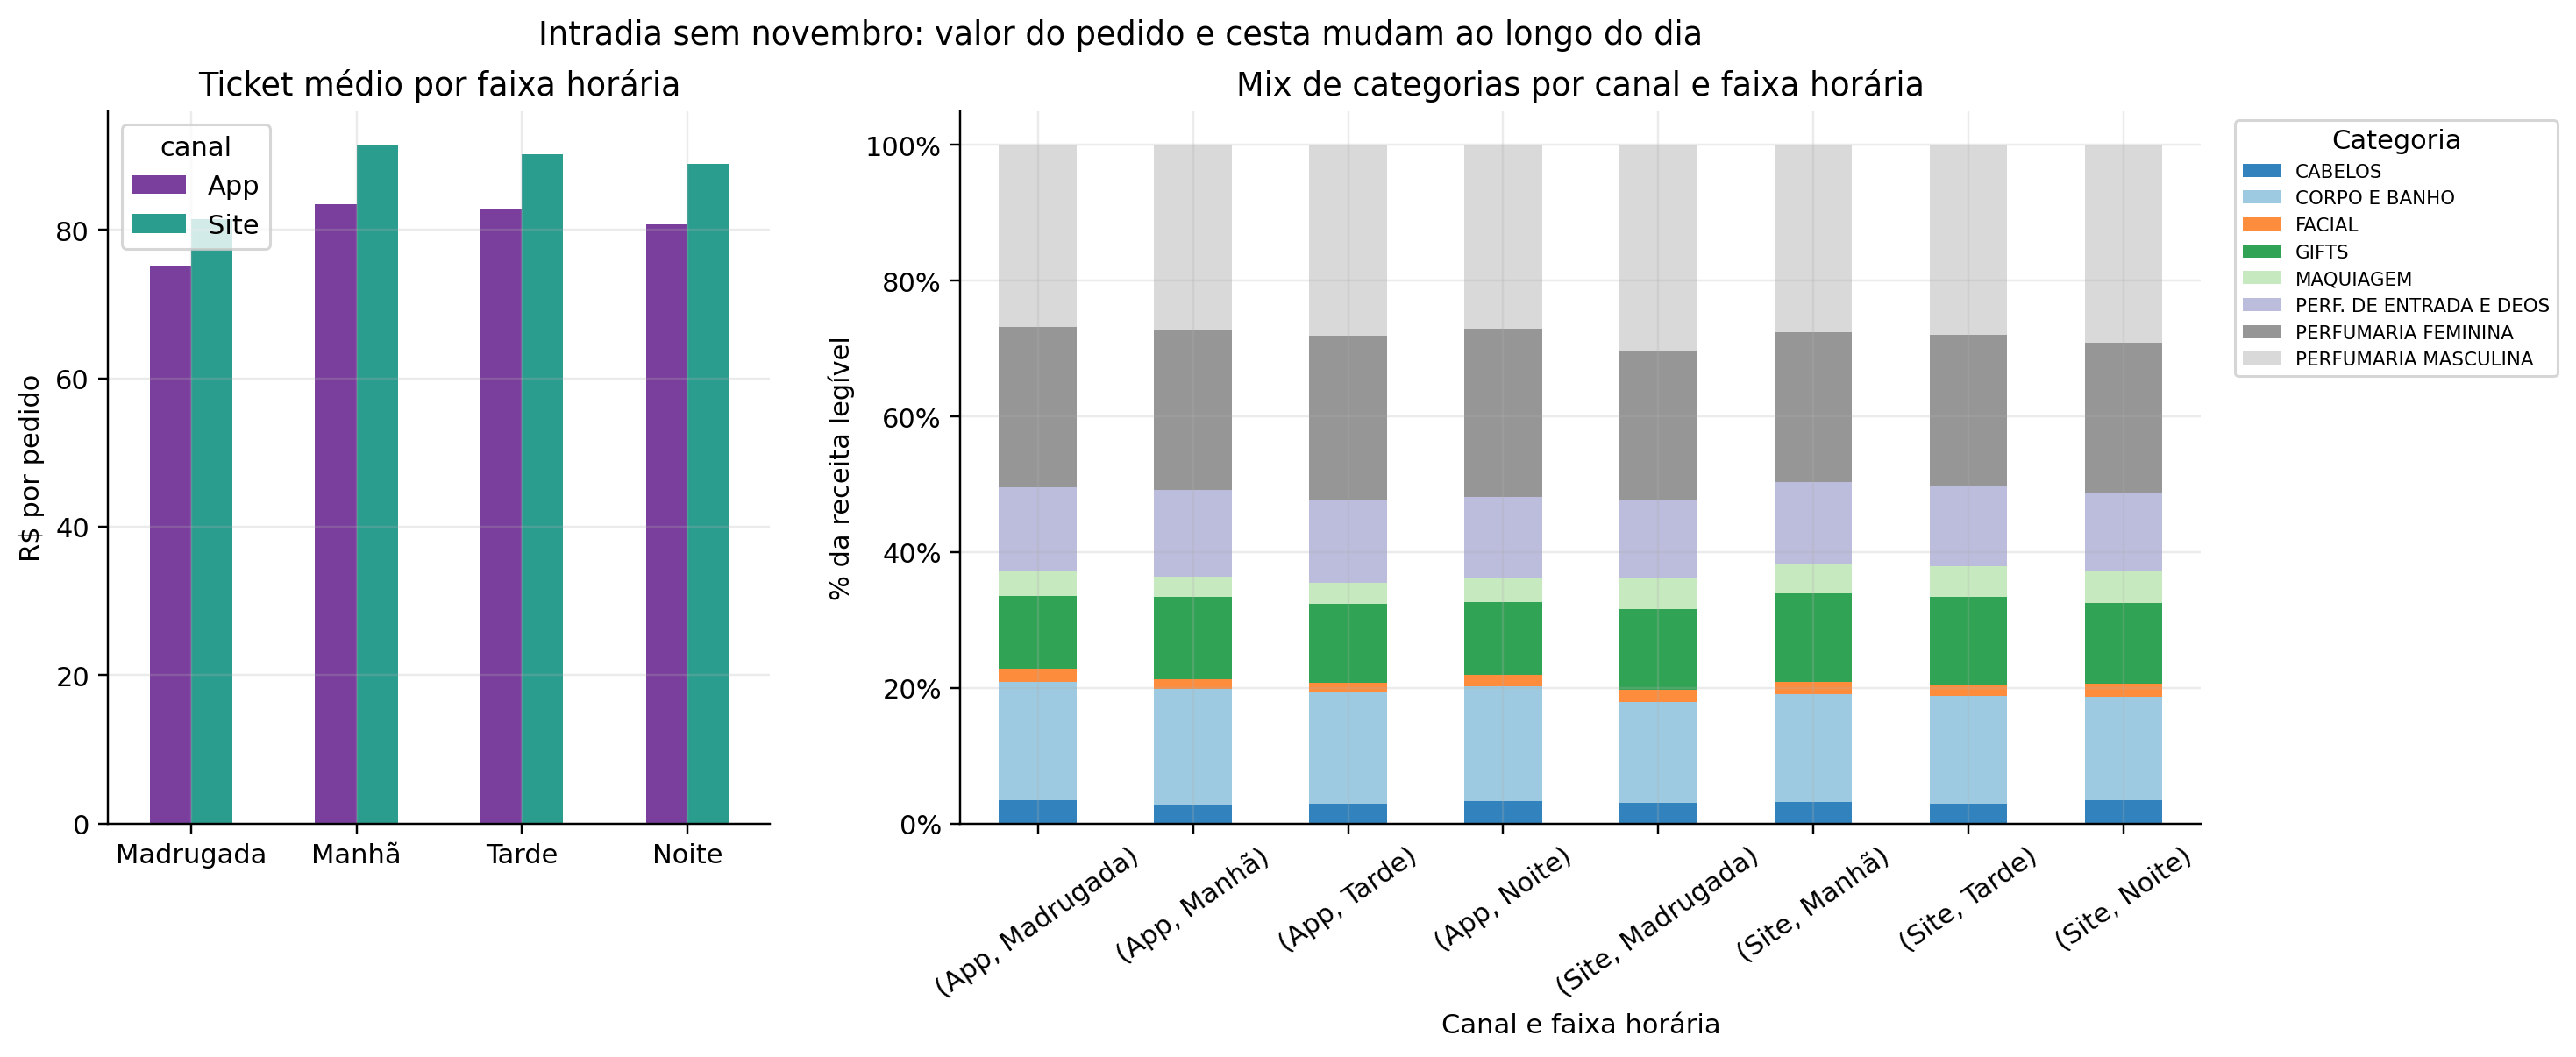

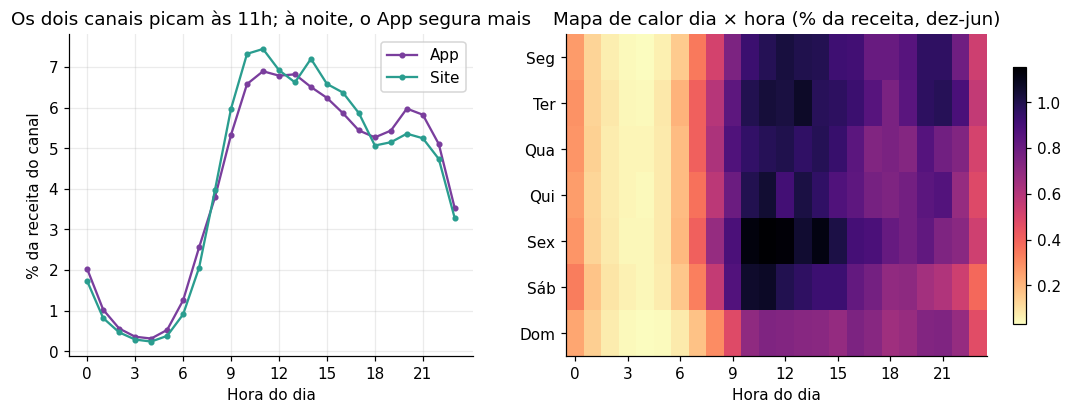

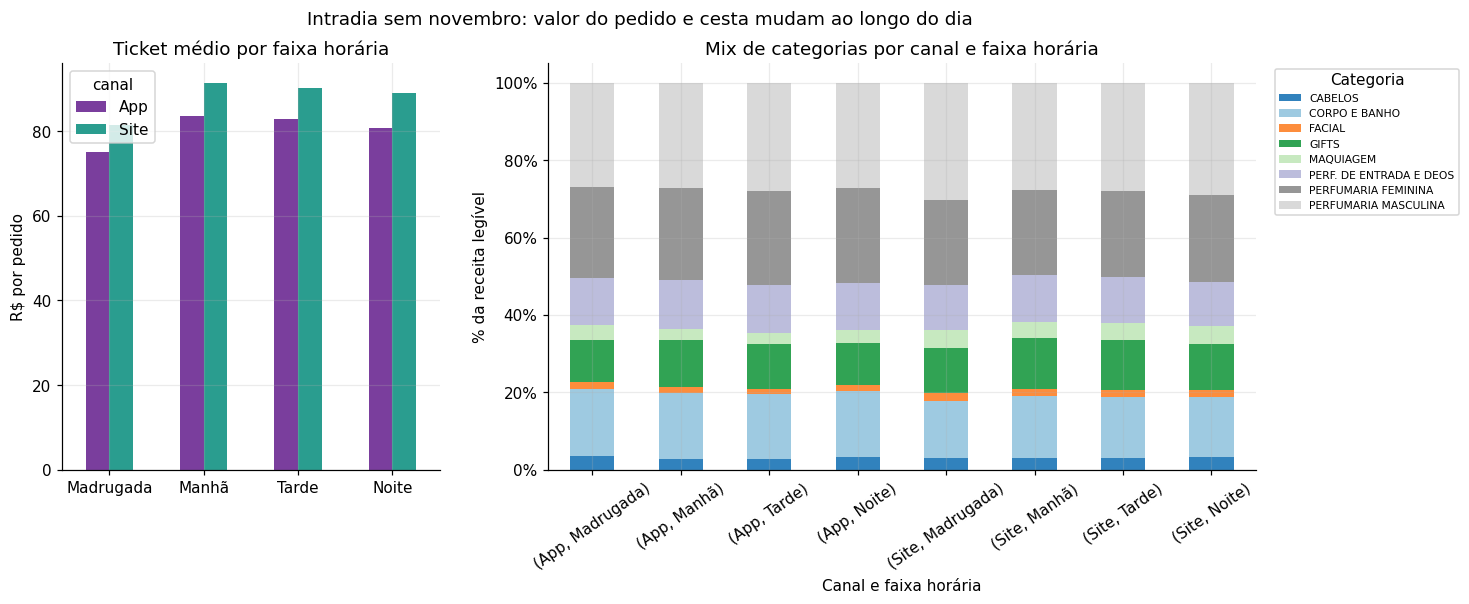

In [6]:
eda.fig_intradia(g); display(Image("reports/figures/eda_03_intradia.png"))
ticket_faixa, mix_faixa = eda.intradia_ticket_mix(g)
display(ticket_faixa)
display((mix_faixa * 100).round(1))
eda.fig_intradia_ticket_mix(g)
display(Image("reports/figures/eda_07_intradia_ticket_mix.png"))

**Leitura** (dez-jun; novembro excluído)
- **Os dois canais picam às 11h; à noite, o App segura mais.** O Site também sobe às 20h, portanto não há um segundo pico exclusivo do App.
- Ticket e mix por faixa horária mostram se a diferença noturna vem de pedidos mais valiosos ou de outra cesta, e tornam a leitura acionável para CRM e banners.
- O mapa de calor mostra a sexta de manhã como o horário mais quente e o domingo frio o dia todo.
- Uso prático: concentrar disparos perto das janelas fortes e testar criativos específicos para a cesta noturna do App.

## 5. Preço médio, ticket e desconto

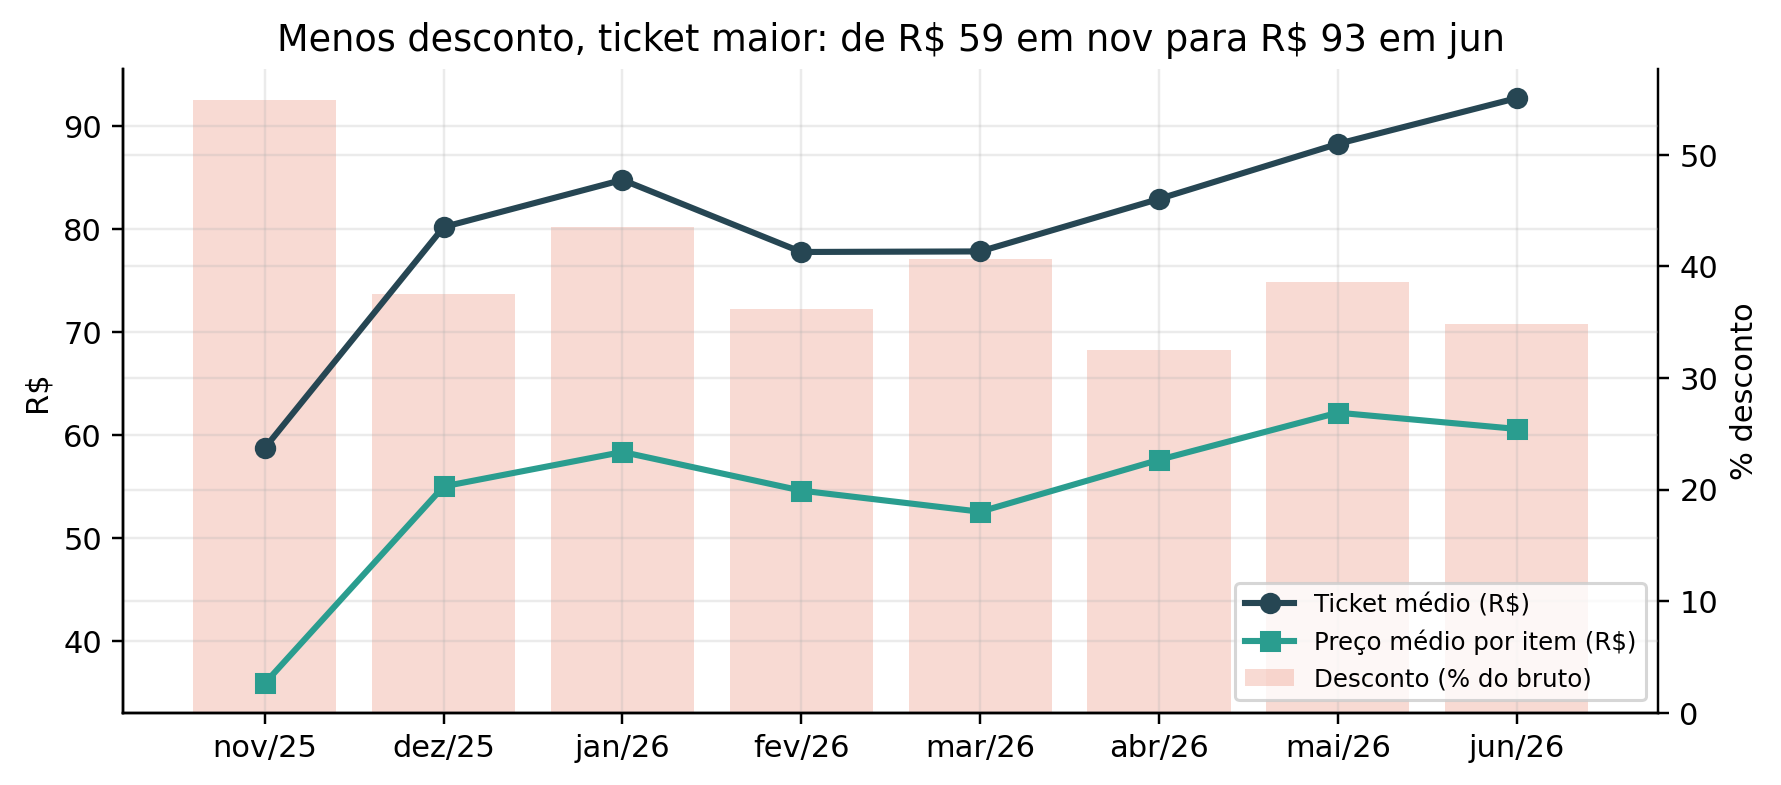

,ticket_medio,preco_medio,itens_por_pedido,taxa_desconto,estorno_pct
mes,,,,,
2025-11,58.76,35.89,1.64,0.55,0.05
2025-12,80.23,55.02,1.46,0.38,0.04
2026-01,84.81,58.37,1.45,0.44,0.04
2026-02,77.80,54.61,1.42,0.36,0.05
2026-03,77.86,52.56,1.48,0.41,0.04
2026-04,82.96,57.60,1.44,0.33,0.04
2026-05,88.31,62.19,1.42,0.39,0.04
2026-06,92.75,60.61,1.53,0.35,0.04


Estornos por mês (R$ e % da receita)


,estorno_rs,estorno_pct_receita
mes,,
2025-11,"5,841,561.09",0.05
2026-05,"2,864,708.90",0.04
2025-12,"2,768,553.52",0.04
2026-03,"2,318,879.49",0.04
2026-01,"2,053,492.36",0.04
2026-06,"1,839,231.40",0.04
2026-04,"1,750,053.44",0.04
2026-02,"1,615,349.33",0.05


Estornos por canal


,estorno_rs,estorno_pct_receita
canal,,
App,"16,197,443.40",0.04
Site,"4,854,386.13",0.04


Estornos por categoria


,estorno_rs,estorno_pct_receita
categoria,,
PERFUMARIA FEMININA,"5,642,496.07",0.05
PERFUMARIA MASCULINA,"5,087,520.47",0.04
CORPO E BANHO,"2,901,295.49",0.04
PERF. DE ENTRADA E DEOS,"2,081,865.19",0.04
GIFTS,"2,077,178.01",0.04
Nao mapeada,"1,245,101.61",0.04
CABELOS,"813,835.17",0.05
MAQUIAGEM,"805,977.58",0.05
FACIAL,"396,559.94",0.05


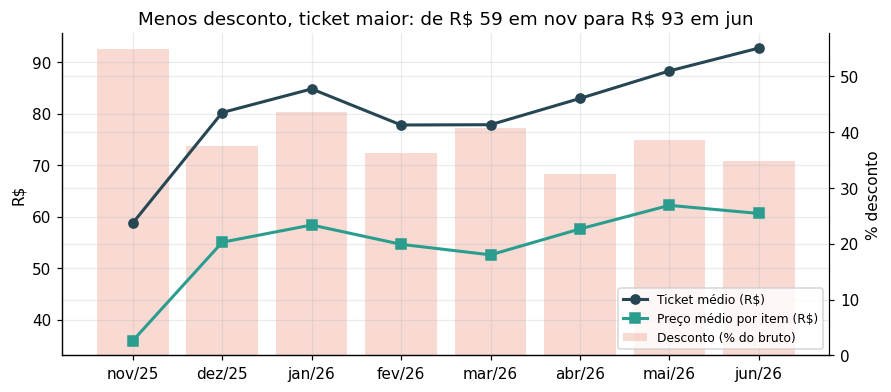

In [7]:
eda.fig_preco_desconto(g); display(Image("reports/figures/eda_04_preco_desconto.png"))
display(eda.mensal(g)[["ticket_medio", "preco_medio", "itens_por_pedido", "taxa_desconto", "estorno_pct"]])
print("Estornos por mês (R$ e % da receita)")
display(eda.estornos_por_dimensao(g, "mes")[["estorno_rs", "estorno_pct_receita"]])
print("Estornos por canal")
display(eda.estornos_por_dimensao(g, "canal")[["estorno_rs", "estorno_pct_receita"]])
print("Estornos por categoria")
display(eda.estornos_por_dimensao(g, "categoria")[["estorno_rs", "estorno_pct_receita"]])

**Leitura**
- **Ticket médio sobe de R$ 59 (nov) para R$ 93 (jun)** enquanto o desconto cai de 55% para 35% do preço cheio. Fora de novembro, o ticket varia de aproximadamente R$ 78 a R$ 93.
- Itens por pedido ficam estáveis (~1,5): **o ganho vem de preço por item, não de cesta maior**.
- **Estornos ficam entre 3,9% e 4,6% da receita por mês**, somando R$ 21,05 mi (R$ 2,63 mi/mês no período). A estabilidade por mês, canal e categoria sugere uma frente operacional; o próximo passo é abrir por motivo.
- Premissa: `taxa_desconto = desconto / (receita + desconto)`, assumindo receita líquida.

## 6. Categoria × dia da semana

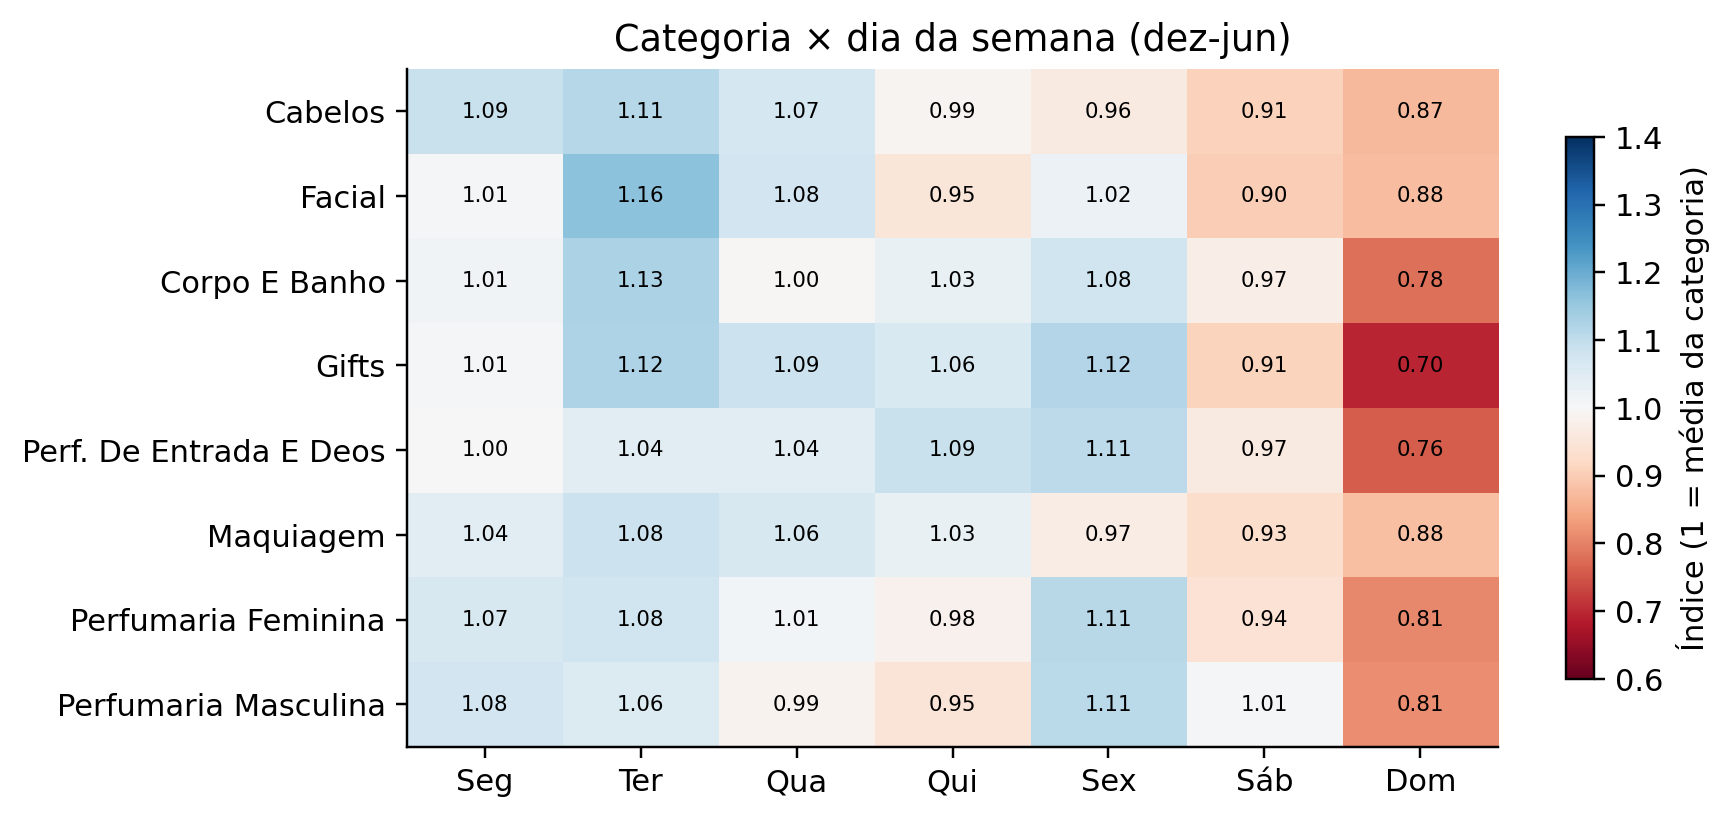

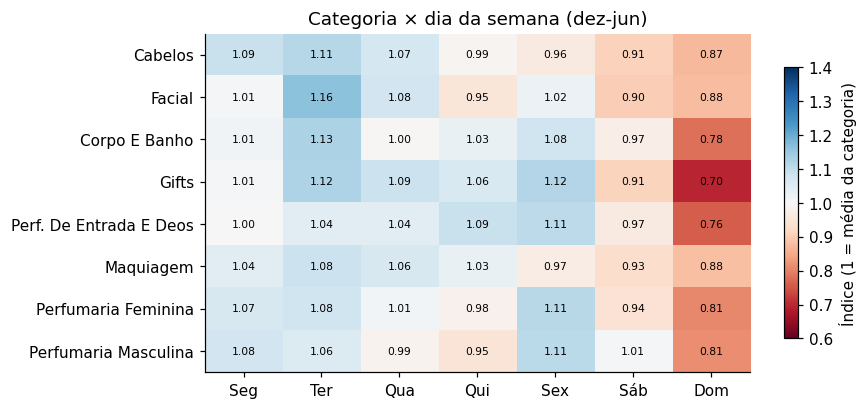

In [8]:
eda.fig_categoria_dia(g); display(Image("reports/figures/eda_05_categoria_dia.png"))

**Leitura**
- **Não existe "dia de categoria"**: todas seguem o mesmo padrão semanal (dias úteis fortes, domingo fraco). A hipótese do handoff (perfumaria qui/sex, maquiagem sáb) não se confirma.
- **Gifts é a mais sensível ao dia** (domingo −30%): compra de presente é planejada na semana.

## 7. Efeito payday

In [9]:
from scipy.stats import mannwhitneyu
d = to_daily(g); d = d[d["data"].dt.month != 11].copy()
eventos = pd.to_datetime(["2025-12-01", "2025-12-25", "2026-03-15", "2026-04-05", "2026-05-10", "2026-06-12"])
d = d[~d["data"].apply(lambda x: (abs((eventos - x).days) <= 3).any())]
d["dia_semana"], d["mes"] = d["data"].dt.dayofweek, d["data"].dt.to_period("M")
d["indice"] = d["receita"] / d.groupby(["mes", "dia_semana"])["receita"].transform("mean")
d["janela"] = pd.cut(d["data"].dt.day, [0, 4, 7, 19, 22, 31], labels=["1-4", "5-7 (salário)", "8-19", "20-22 (adiantamento)", "23-31"])
display(d.groupby("janela", observed=True)["indice"].agg(["mean", "count"]))
mannwhitneyu(d.loc[d["data"].dt.day.isin([5, 6, 7]), "indice"], d.loc[~d["data"].dt.day.isin([5, 6, 7]), "indice"])

,mean,count
janela,,
1-4,1.01,21
5-7 (salário),1.22,17
8-19,1.04,63
20-22 (adiantamento),1.00,20
23-31,0.88,52


MannwhitneyuResult(statistic=np.float64(2116.0), pvalue=np.float64(5.6716695352064784e-05))

**Leitura**
- Índice = receita do dia ÷ média do mesmo dia da semana no mesmo mês (controla calendário), sem novembro e sem datas especiais.
- **Dias 5 a 7 vendem ~22% acima do esperado; dias 20 a 22, neutros.** O salário move a venda; o adiantamento, não.
- Ressalva: pode haver campanha recorrente no início do mês; sem calendário de campanhas, não dá para separar. Virou feature (`is_payday_5`, D08).

## 8. Participação dos canais

In [10]:
eda.share_canal_mensal(g)

canal,App,Site
mes,,
2025-11,0.76,0.24
2025-12,0.72,0.28
2026-01,0.75,0.25
2026-02,0.75,0.25
2026-03,0.77,0.23
2026-04,0.78,0.22
2026-05,0.78,0.22
2026-06,0.79,0.21


**Leitura**: o **App sobe de 72% (dez) para 79% (jun)** da receita. O e-commerce está migrando para o App; o Site tem ticket ~10% maior e desconto menor.

## 9. Estrutura estatística da série (para a modelagem)

ADF (dez-jun):  p = 0.008  (H0: não estacionária)
KPSS (dez-jun): p = 0.100  (H0: estacionária)
Força da sazonalidade semanal: 0.26
Tendência log-linear, controlada por dia da semana: -0.5%/30 dias; p = 0.793


C:\Users\Matheus\AppData\Local\Temp\ipykernel_34660\3891385073.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  print(f"KPSS (dez-jun): p = {kpss(pos_nov, regression='c', nlags='auto')[1]:.3f}  (H0: estacionária)")


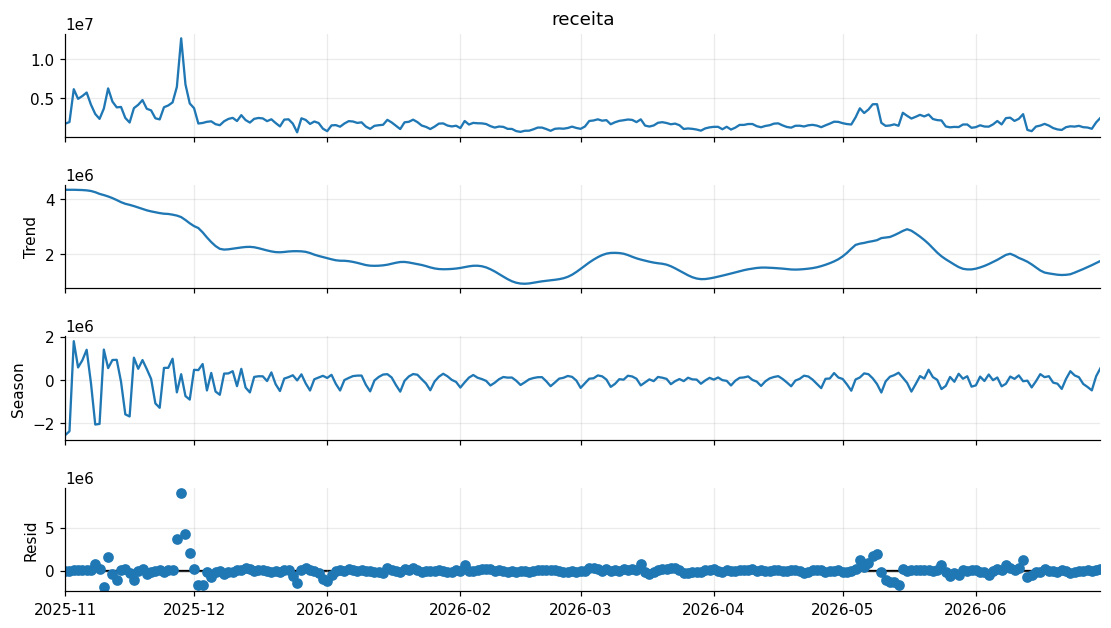

In [11]:
import warnings
warnings.simplefilter("ignore")
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
serie = to_daily(g).set_index("data")["receita"].asfreq("D")
stl = STL(serie, period=7, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 6); fig.savefig("reports/figures/eda_06_stl.png", bbox_inches="tight")
pos_nov = serie["2025-12-01":]
print(f"ADF (dez-jun):  p = {adfuller(pos_nov)[1]:.3f}  (H0: não estacionária)")
print(f"KPSS (dez-jun): p = {kpss(pos_nov, regression='c', nlags='auto')[1]:.3f}  (H0: estacionária)")
var = stl.seasonal.var() / (stl.seasonal.var() + stl.resid.var())
print(f"Força da sazonalidade semanal: {var:.2f}")

import numpy as np
import statsmodels.formula.api as smf
tendencia = pd.DataFrame({"receita": pos_nov.values, "t": np.arange(len(pos_nov)), "dia_semana": pos_nov.index.dayofweek})
reg = smf.ols("np.log(receita) ~ t + C(dia_semana)", tendencia).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
print(f"Tendência log-linear, controlada por dia da semana: {100 * (np.exp(30 * reg.params['t']) - 1):+.1f}%/30 dias; p = {reg.pvalues['t']:.3f}")

**Leitura**
- A decomposição separa nível, sazonalidade semanal e resíduo (os eventos).
- **De dezembro a junho a série é estacionária** (ADF p = 0,008; KPSS não rejeita estacionariedade). A evidência de ausência de tendência vem da regressão log-linear controlada por dia da semana (p ≈ 0,79), não do ADF.
- **A sazonalidade semanal explica só ~26%** da variação não-tendencial; eventos e choques dominam. Isso exige testar modelos estatísticos e modelos com calendário nas mesmas origens.